# **Inteligencia Artificial y Aprendizaje Automático**
## **Maestría en Inteligencia Artificial Aplicada**
### **Dr Luis Eduardo Falcón Morales**
### **Tecnológico de Monterrey**
## **Actividad Individual Semana 9: Pronósticos con Series de Tiempo**


#### **Nombre: José Florencio Maguey Peralta**
#### **Matrícula: A01796727**

In [1]:
pip install statsforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.4/354.4 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.8/275.8 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.3/135.3 kB 6.3 MB/s eta 0:00:00


In [2]:
## ++++++++++ Incluye todas las celdas y líneas de código que requieras +++++++++++++++++++++++++
import kagglehub

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
import math

from prophet import Prophet
from statsmodels.graphics.tsaplots import month_plot, quarter_plot
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf   # gráficos de autocorrelación


from statsforecast import StatsForecast
from statsforecast.models import Naive, SeasonalNaive, ARIMA
from prophet import Prophet

In [3]:
# Download latest version
path = kagglehub.dataset_download("piyushagni5/monthly-sales-of-french-champagne")

print("Path to dataset files:", path)

100%|██████████| 713/713 [00:00<00:00, 878kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/piyushagni5/monthly-sales-of-french-champagne/versions/1


In [4]:
df_champ=pd.read_csv(path+"/monthly_champagne_sales.csv")
df_champ.head()

,Month,Sales
0,1964-01,2815
1,1964-02,2672
2,1964-03,2755
3,1964-04,2721
4,1964-05,2946


In [5]:
df_champ.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Month   105 non-null    object
 1   Sales   105 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 1.8+ KB


Ingenuo

In [6]:
df_champ.columns=['ds','y']#renombras columnas
df_champ['ds']=pd.to_datetime(df_champ['ds'], dayfirst=True) #da el formato de fecha
df_champ.set_index('ds',inplace=True) #el campo fecha se vuelve el índice de la tabla
df_champ.index.freq='MS' #se indica que el índice tienen una frecuencia mensual, esto ayuda para por jugar con el tiempo
df_champ.head()

,y
ds,
1964-01-01,2815
1964-02-01,2672
1964-03-01,2755
1964-04-01,2721
1964-05-01,2946


In [7]:
df_champ.tail()

,y
ds,
1972-05-01,4618
1972-06-01,5312
1972-07-01,4298
1972-08-01,1413
1972-09-01,5877


In [8]:
train = df_champ.loc[df_champ.index < '1972-01-01']
test = df_champ.loc[df_champ.index >= '1972-01-01']   # Seleccionamos los datos del último año para predicción de Test.

In [9]:
print('----------------------------------Shape  df_champ:---------------------------')
print(df_champ.shape)
print('----------------------------------Shape  train:---------------------------')
print(train.shape)
print('----------------------------------Shape  test:---------------------------')
print(test.shape)

----------------------------------Shape  df_champ:---------------------------
(105, 1)
----------------------------------Shape  train:---------------------------
(96, 1)
----------------------------------Shape  test:---------------------------
(9, 1)


<ipython-input-10-276012c9c901>:6: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  plt.plot(rolling_mean, color='orange', label='Promedio móvil (12 meses)')


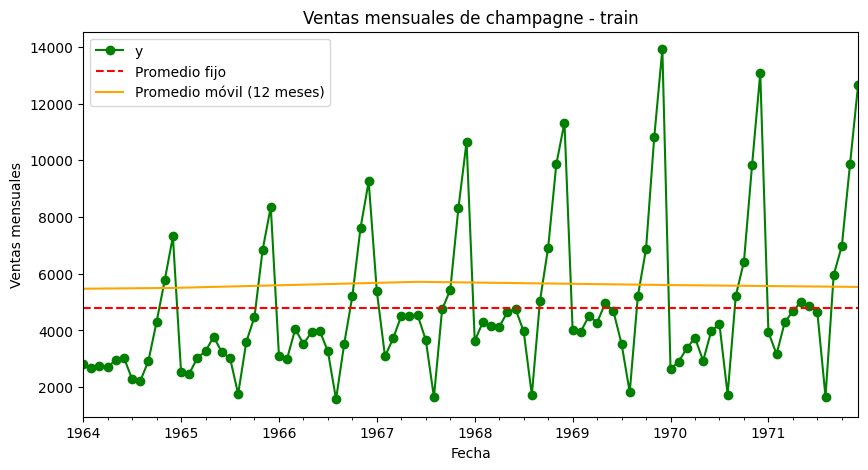

In [10]:
rolling_mean = train.rolling(window=12).mean()

# Crear el gráfico
train.plot(figsize=(10, 5), color='g', title='Ventas mensuales de champagne - train', marker='o')
plt.axhline(y=np.mean(train), color='r', linestyle='--', label='Promedio fijo')
plt.plot(rolling_mean, color='orange', label='Promedio móvil (12 meses)')
plt.xlabel('Fecha')
plt.ylabel('Ventas mensuales')
plt.legend()
plt.show()

Del gráfico puedo observar los siguiente:

1. Las ventas tienen estacionalidad, esta inciando en septiembre y concluyendo en diciembre.
2. El volumen promedio vendido es alredor de los 420 botellas mensuales, considerando la estacionalidad del producto.
3. Considerando la media móvil de 12 meses, podemos observar que el promedio se encuentra entre las 590 unidades mensuales.
4. Los picos de la estacionalidad tiene dos tipos de tendencia, una positiva que va desde 1964 hasta 19070, y una negativa en los años posteriores.

Naive

In [11]:
train['unique_id'] = 'champagne_sales'  # Add a 'unique_id' column with a single value
test['unique_id'] = 'champagne_sales'
train = train.reset_index()
test = test.reset_index()

<ipython-input-11-09644ecfd213>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['unique_id'] = 'champagne_sales'  # Add a 'unique_id' column with a single value
<ipython-input-11-09644ecfd213>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['unique_id'] = 'champagne_sales'


In [12]:
hor = test.index.nunique() #el horizonte (tiempo) que determinemos. la función nunique saca los distintos y los cuenta, en nuestro caso son 9 valores distintos
#el modelo tien un grid o lista.
#escogemos dos tipos, el naive que no lleva parámetros, y el seasonalnaive que sólo lleva el season_length
model = StatsForecast(models=[Naive(),
                              SeasonalNaive(season_length=12),
                              ],
                      freq='M', n_jobs=-1)
model.fit(train)

df_fcst_nv = model.predict(
                            h=hor, #es le horizonte
                            level=[90] #el intervalo de confianza
                          )
df_fcst_nv=pd.concat([df_fcst_nv,test['y']],axis=1)
df_fcst_nv

/usr/local/lib/python3.11/dist-packages/utilsforecast/processing.py:384: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.11/dist-packages/utilsforecast/processing.py:440: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  freq = pd.tseries.frequencies.to_offset(freq)


,unique_id,ds,Naive,Naive-lo-90,Naive-hi-90,SeasonalNaive,SeasonalNaive-lo-90,SeasonalNaive-hi-90,y
0,champagne_sales,1971-12-31,12670.0,8457.098633,16882.900391,3934.0,2545.38623,5322.61377,4348
1,champagne_sales,1972-01-31,12670.0,6712.058105,18627.941406,3162.0,1773.38623,4550.61377,3564
2,champagne_sales,1972-02-29,12670.0,5373.041016,19966.958984,4286.0,2897.38623,5674.61377,4577
3,champagne_sales,1972-03-31,12670.0,4244.197754,21095.802734,4676.0,3287.38623,6064.61377,4788
4,champagne_sales,1972-04-30,12670.0,3249.666504,22090.333984,5010.0,3621.38623,6398.61377,4618
5,champagne_sales,1972-05-31,12670.0,2350.541748,22989.458984,4874.0,3485.38623,6262.61377,5312
6,champagne_sales,1972-06-30,12670.0,1523.711182,23816.289062,4633.0,3244.38623,6021.61377,4298
7,champagne_sales,1972-07-31,12670.0,754.116028,24585.884766,1659.0,270.38623,3047.61377,1413
8,champagne_sales,1972-08-31,12670.0,31.296446,25308.703125,5951.0,4562.38623,7339.61377,5877


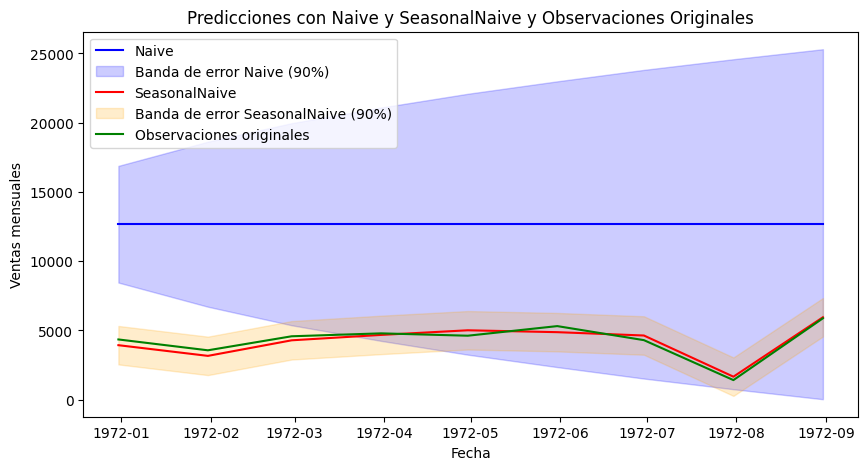

In [13]:
fig, ax = plt.subplots(figsize=(10,5))

# Línea y banda de error para Naive
ax.plot(df_fcst_nv['ds'], df_fcst_nv['Naive'], color='b', label='Naive')  # Línea de Naive
ax.fill_between(
    df_fcst_nv['ds'],
    df_fcst_nv['Naive-lo-90'],
    df_fcst_nv['Naive-hi-90'],
    color='b', alpha=0.2, label='Banda de error Naive (90%)'  # Banda de error azul
)

# Línea y banda de error para SeasonalNaive
ax.plot(df_fcst_nv['ds'], df_fcst_nv['SeasonalNaive'], color='r', label='SeasonalNaive')  # Línea de SeasonalNaive
ax.fill_between(
    df_fcst_nv['ds'],
    df_fcst_nv['SeasonalNaive-lo-90'],
    df_fcst_nv['SeasonalNaive-hi-90'],
    color='orange', alpha=0.2, label='Banda de error SeasonalNaive (90%)'  # Banda de error roja
)

# Línea de las observaciones originales
ax.plot(df_fcst_nv['ds'], df_fcst_nv['y'], color='green', label='Observaciones originales')  # Línea de y

# Configuración del gráfico
ax.set_title('Predicciones con Naive y SeasonalNaive y Observaciones Originales')
ax.set_xlabel('Fecha')
ax.set_ylabel('Ventas mensuales')
ax.legend()  # Mostrar leyendas

plt.show()

In [14]:
# Calculamos la raíz del error cuadrático medio (RMSE):
df_rmse= df_fcst_nv[['ds', 'Naive', 'SeasonalNaive', 'y']]
print('---------RMSE - Naive---------')
print(np.sqrt(mean_squared_error(df_rmse['y'], df_rmse['Naive'])))
print('--------- RMSE - Seasonal Naive---------')
print(np.sqrt(mean_squared_error(df_rmse['y'], df_rmse['SeasonalNaive'])))

---------RMSE - Naive---------
8444.114636834343
--------- RMSE - Seasonal Naive---------
325.5678812667183


ARIMA

In [15]:
train.set_index('ds',inplace=True) #el campo fecha se vuelve el índice de la tabla
train.index.freq='MS'
test.set_index('ds',inplace=True) #el campo fecha se vuelve el índice de la tabla
test.index.freq='MS'

In [16]:
train.drop('unique_id',axis=1,inplace=True)
test.drop('unique_id',axis=1,inplace=True)

<ipython-input-17-027daec1c7aa>:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  decomposition = seasonal_decompose(train['y'].resample('M').mean(), model='multiplicative')  # <<<---- Observa que el modelo es multiplicativo


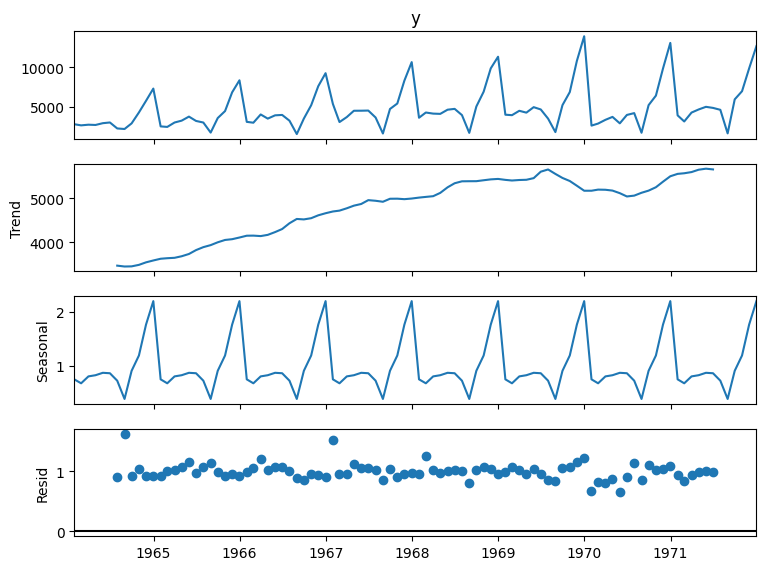

In [17]:
decomposition = seasonal_decompose(train['y'].resample('M').mean(), model='multiplicative')  # <<<---- Observa que el modelo es multiplicativo
fig = decomposition.plot()
fig.set_size_inches(8,6)
plt.show()

<ipython-input-18-e6589d8b739a>:1: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  fig = quarter_plot(train['y'].resample('Q').mean(), ylabel='ventas')


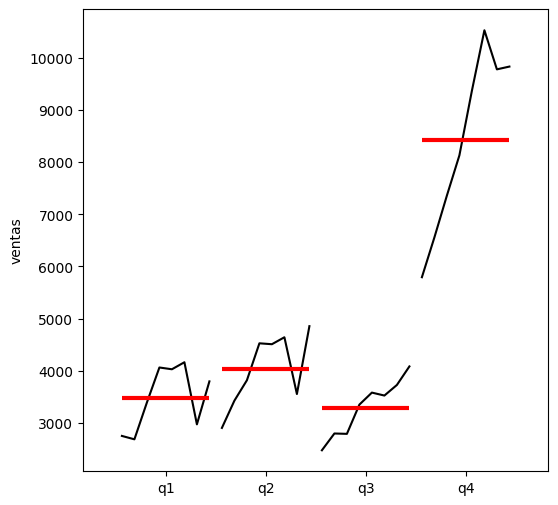

In [18]:
fig = quarter_plot(train['y'].resample('Q').mean(), ylabel='ventas')
fig.set_size_inches(6,6)
plt.show()

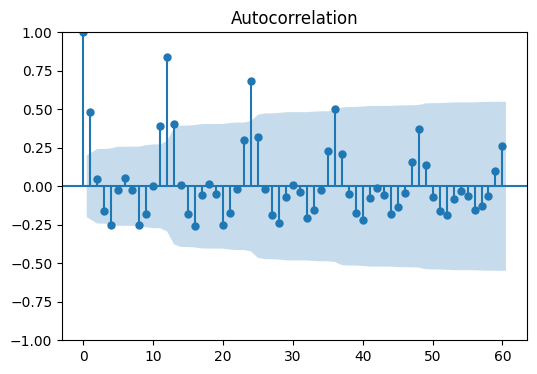

In [19]:
fig,ax = plt.subplots(figsize = (6,4))
plot_acf(train['y'], lags=60, ax=ax)
plt.show()

**mover los lags...seguramente ahí algo anda mal**

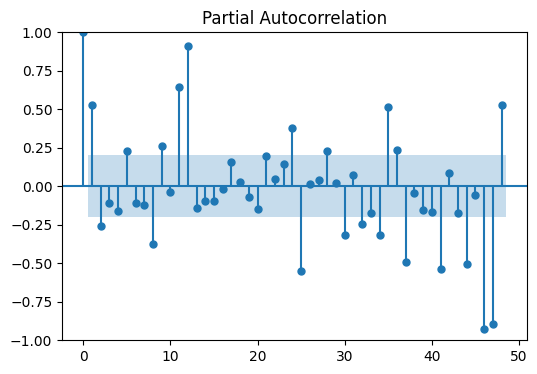

In [20]:
fig, ax = plt.subplots(figsize = (6,4))
# Reduced lags to be within 50% of the sample size
plot_pacf(train['y'], lags = 48, ax = ax, method="ols")   # ols: regression of time series on lags of it an on constant. predetrminado method="ywm"
plt.show()

In [21]:
arima = ARIMA(order=(2,0,1), season_length=12)
arima = arima.fit(y=train['y'])
df_fcst_ARIMA = pd.DataFrame(arima.predict(h=hor, level=[95]))
df_fcst_ARIMA['ds']=test.index
df_fcst_ARIMA=pd.merge(df_fcst_ARIMA,test,on='ds', how='right')

/usr/local/lib/python3.11/dist-packages/statsforecast/arima.py:1123: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return np.all(x[0] == x)


In [22]:
print('---------RMSE - ARIMA ---------')
print(np.sqrt(mean_squared_error(df_fcst_ARIMA['y'], df_fcst_ARIMA['mean'])))

---------RMSE - ARIMA ---------
2118.3136744866692


In [23]:
from statsmodels.tsa.arima.model import ARIMA

# Lo primero es para quitar la estacionalidad y transformar un problema
# de tipo no-estacionario (SARIMA) en uno estacionario (ARIMA):

# Diferencia de datos consecutivos en el tiempo
# y podemos ahora usar ARIMA:
def difference(dataset, interval=1):
  diff = list()

  for i in range(interval, len(dataset)):
    value = dataset[i] - dataset[i - interval]
    diff.append(value)

  return np.array(diff)



# Invierte las diferencias anteriores, es decir, nos regresa la estacionalidad:
def inverse_difference(history, yhat, interval=1):
  return yhat + history[-interval]

# Definamos la siguiente lista de registros de pasajeros en el tiempo:
history = [x for x in train.loc[:,'y'].values]   # train-ndarray : columna solo con los registros de pasajeros "y".
                               # history-list : lista con los datos del train.

predictions = list()   # Para incluir las predicciones que vaya generando el modelo.

for i in range(len(test['y'])):
  #
  months_in_year = 12
  diff = difference(history, months_in_year)    # diff-list: lista de los datos de diferencias para transformar SARIMA en ARIMA.

  # Generamos el modelo.
  model = ARIMA(diff, order=(2,0,1),) # Si aplicamos diff, entonces d=0 es aplicable.
  model_fit = model.fit(method_kwargs={'maxiter':300})  # Aumentar las iteraciones para evitar el WarningConvergence.

  yhat = model_fit.forecast()[0]   # prediccions (yhat) de cada registro, es un solo número flotante.
  yhat = inverse_difference(history, yhat, months_in_year)    # El "history" sigue siendo la lista de arriba.
                                                              # El nuevo "yhat" es cada un nuevo valor (float) de predicción.
  predictions.append(yhat)  # predictions-list : lista que se va incrementando al ir agregando cada predicción nueva.

  # Observaciones-reales:
  obs = test.iloc[i]['y']   #  cada dato es un flotante.
  history.append(obs)   #  history-list : se va incrementado a partir del Train con los registros-observaciones reales.

  print('>Esperado-real = %3d, Predicción = %.3f' % (obs, yhat))

# Error RMSE:
rmse = np.sqrt(mean_squared_error(test['y'].values, predictions))
print('\nError-Modelo-ARIMA: RMSE: %.3f' % rmse)

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


>Esperado-real = 4348, Predicción = 4092.979
>Esperado-real = 3564, Predicción = 3453.459
>Esperado-real = 4577, Predicción = 4603.168
>Esperado-real = 4788, Predicción = 4981.823
>Esperado-real = 4618, Predicción = 5278.687
>Esperado-real = 5312, Predicción = 5026.703
>Esperado-real = 4298, Predicción = 4924.605
>Esperado-real = 1413, Predicción = 1821.769
>Esperado-real = 5877, Predicción = 6094.070

Error-Modelo-ARIMA: RMSE: 371.222


Prophet

In [24]:
train = df_champ.iloc[0:-12,:]
test = df_champ.iloc[-12:,:]

In [25]:
train.reset_index(inplace=True)
test.reset_index(inplace=True)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmprwtm56gm/kru9jen2.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmprwtm56gm/0xaxpd3k.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=47787', 'data', 'file=/tmp/tmprwtm56gm/kru9jen2.json', 'init=/tmp/tmprwtm56gm/0xaxpd3k.json', 'output', 'file=/tmp/tmprwtm56gm/prophet_model5r_a6jz2/prophet_model-20250311023944.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
02:39:44 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
02:39:45 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


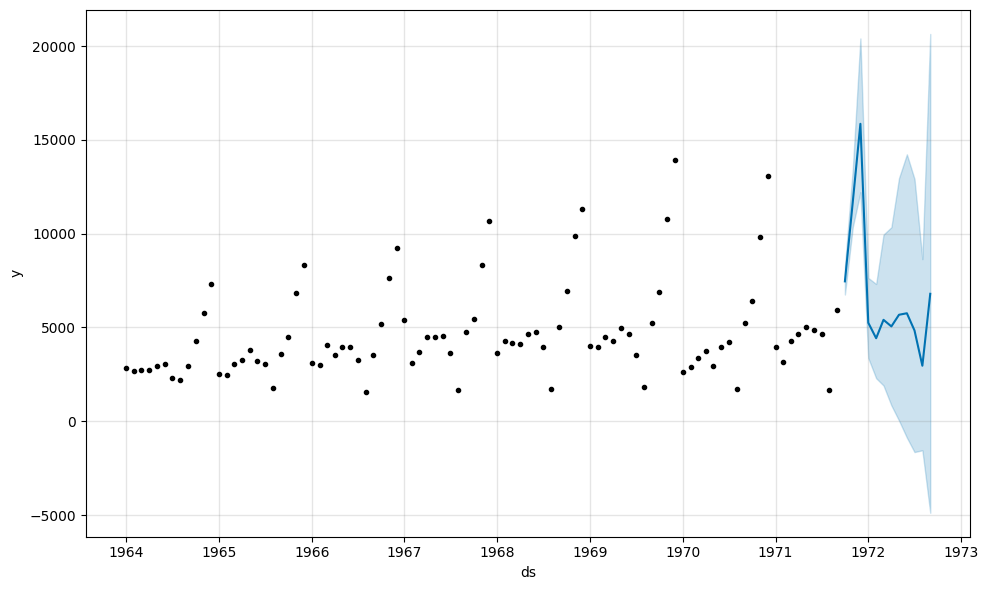

In [26]:
m = Prophet(
              seasonality_mode='multiplicative',
              yearly_seasonality=True,
              interval_width=0.95,
              changepoint_prior_scale=10,
              seasonality_prior_scale=18
            )
m.fit(train)
future = m.make_future_dataframe(periods=12, freq='MS')
fcst = m.predict(test)
fig = m.plot(fcst)

In [27]:
print('---------RMSE - PROPHET ---------')
print(np.sqrt(mean_squared_error(test['y'], fcst['yhat'])))
fcst

---------RMSE - PROPHET ---------
1322.2661997084176


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yearly,yearly_lower,yearly_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat
0,1971-10-01,6394.857918,6758.537191,8229.239767,6147.212819,6722.199342,0.166403,0.166403,0.166403,0.166403,0.166403,0.166403,0.0,0.0,0.0,7458.981919
1,1971-11-01,6488.369507,10354.008164,13426.974373,5716.551865,7470.393778,0.802292,0.802292,0.802292,0.802292,0.802292,0.802292,0.0,0.0,0.0,11693.933247
2,1971-12-01,6578.864593,12210.439803,20407.410288,5202.342821,8485.180496,1.410212,1.410212,1.410212,1.410212,1.410212,1.410212,0.0,0.0,0.0,15856.459526
3,1972-01-01,6672.376181,3371.628432,7644.200398,4469.710319,9595.836429,-0.212580,-0.212580,-0.212580,-0.212580,-0.212580,-0.212580,0.0,0.0,0.0,5253.965257
4,1972-02-01,6765.887770,2296.153300,7318.880382,3589.330678,10975.034389,-0.345510,-0.345510,-0.345510,-0.345510,-0.345510,-0.345510,0.0,0.0,0.0,4428.206646
5,1972-03-01,6853.366353,1908.167933,9952.843445,2391.528669,12619.675263,-0.210878,-0.210878,-0.210878,-0.210878,-0.210878,-0.210878,0.0,0.0,0.0,5408.143152
6,1972-04-01,6946.877942,846.318622,10345.707788,1284.514703,14193.595181,-0.271953,-0.271953,-0.271953,-0.271953,-0.271953,-0.271953,0.0,0.0,0.0,5057.653341
7,1972-05-01,7037.373028,40.396112,12960.774020,153.055489,15753.062984,-0.193043,-0.193043,-0.193043,-0.193043,-0.193043,-0.193043,0.0,0.0,0.0,5678.860864
8,1972-06-01,7130.884616,-869.878023,14230.672577,-1138.398973,17446.923910,-0.192369,-0.192369,-0.192369,-0.192369,-0.192369,-0.192369,0.0,0.0,0.0,5759.124005
9,1972-07-01,7221.379702,-1638.974081,12916.461275,-2306.253824,19326.192387,-0.329364,-0.329364,-0.329364,-0.329364,-0.329364,-0.329364,0.0,0.0,0.0,4842.914193


LSTM

In [38]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import tensorflow as tf
import keras
from keras import Sequential
from keras import layers
from keras.layers import LSTM, Dense

In [30]:
#se crea la función para hacer las series de tiempo.
#EG: [[1,2,3,4,5]] [6]
#    [[2,3,4,5,6]] [7]....
#     X             y
def creamos_secuencias(data, window_size):
    X, y = [], [] #estas son las listas de las X's y Y's
    for i in range(window_size, len(data)): #le pasa los dos parámetros, el window size en la fila de abajo
                                            #lo resta para que no de error de desbordamiento, porque se sale del bound.
        X.append(data[i-window_size:i])  # Ventana en este ejercicio de 12 meses de manera continua
                      #i-window_size: se indica el mes/periodod a extraer, eg: 1-12 = 11, y así sucesivamente
                      #i-window_size:i >>>indica las fioals de df a extraer, eg: [11:12]...y así sucecsivamente
                      #por úlitmo se agregan con el append
        y.append(data[i])  # y el siguiente mes a predecir, dados los 12 anteriores.
    return np.array(X), np.array(y)

In [32]:
window_size = 12 #se indica la venta de tiempo
X, y = creamos_secuencias(df_champ[['y']].values, window_size)#llamamos a la función de arriba
print(X.shape)  # verifiquemos que el formato es el requerido por la CNN.

(93, 12, 1)


In [48]:
#voy a tomar todas las fechas antes de '1972-01-01' cono train
# Paso 1: Crear las fechas faltantes para completar 12 observaciones
fechas_faltantes = pd.date_range(
    start=df_champ.index[-1] + pd.DateOffset(months=1),  # Continuar a partir de la última fecha
    periods=3,  # Añadir las fechas necesarias (9 + 3 = 12)
    freq='MS'  # Frecuencia mensual
)

# Paso 2: Crear un DataFrame con las fechas faltantes
nuevas_filas = pd.DataFrame(index=fechas_faltantes, columns=df_champ.columns)
nuevas_filas['y'] = None  # Inicializar con NaN o valores predeterminados

# Paso 3: Concatenar el DataFrame original con las nuevas filas
df_champ_expandido = pd.concat([df_champ, nuevas_filas])

# Paso 4: Rellenar valores faltantes (puedes usar interpolación u otra estrategia)
df_champ_expandido['y'] = df_champ_expandido['y'].interpolate(method='linear')
#si los dejamos vacíos le modelo falla, no puede con los NaN

# Paso 5: Dividimos el df en train y test
#ind = df_champ_expandido.loc[df_champ_expandido.index < '1972-01-01'].shape[0]  # Filas que cumplen con la fecha indicada
#X_train, y_train = X[:ind], y[:ind]
#X_test, y_test = X[ind:], y[ind:]

ind = X.shape[0] - 12  # Assuming you want the last 12 observations for testing

X_train, y_train = X[:ind], y[:ind]
X_test, y_test = X[ind:], y[ind:]

<ipython-input-48-5f49d37eb885>:17: FutureWarning: Series.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_champ_expandido['y'] = df_champ_expandido['y'].interpolate(method='linear')


In [49]:
#https://keras.io/api/layers/recurrent_layers/lstm/
model = Sequential()
model.add(LSTM(50,  # total de neuronas de la capa LSTM
               return_sequences=True, # para que siga manteniendo el formato de 3 dimensiones.
               activation='relu',
               recurrent_activation='sigmoid'
               ))  # Capa LSTM
model.add(LSTM(50, return_sequences=False, activation='relu'))
model.add(Dense(1))  # Capa de salida

# Compilamos el modelo
model.compile(optimizer='adam',
              loss='mean_squared_error',
              metrics=[tf.keras.metrics.RootMeanSquaredError()],   #  despliega RMSE
              )

# y llevamos a cabo el entrenamiento con los cunjuntos de entrenamiento y prueba:
history = model.fit(X_train, y_train, epochs=65, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/65
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 357ms/step - loss: 36681836.0000 - root_mean_squared_error: 6055.9307 - val_loss: 46096708.0000 - val_root_mean_squared_error: 6789.4556
Epoch 2/65
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 31156140.0000 - root_mean_squared_error: 5579.7227 - val_loss: 43201584.0000 - val_root_mean_squared_error: 6572.7910
Epoch 3/65
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - loss: 31457486.0000 - root_mean_squared_error: 5607.2119 - val_loss: 41494604.0000 - val_root_mean_squared_error: 6441.6304
Epoch 4/65
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - loss: 30394384.0000 - root_mean_squared_error: 5512.1548 - val_loss: 41485916.0000 - val_root_mean_squared_error: 6440.9561
Epoch 5/65
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step - loss: 32441932.0000 - root_mean_squared_error: 5687.0928 - val_loss: 38080612.0000 - val_root_mean_squared_error: 6170.9492
Epoch 6/65
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step - loss: 26966504.0000 - root_mean_squared_error: 5191.0991 - val_loss: 

In [50]:
pred_LSTM = model.predict(X_test[-12:])
y_test_real = y_test[-12:].reshape(-1, 1)

# Calculamos el RMSE en la escala original de los datos:
rmse = np.sqrt(mean_squared_error(y_test_real, pred_LSTM))
print('\nError-Modelo-FacebookProphet: RMSE: %.3f' % rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step

Error-Modelo-FacebookProphet: RMSE: 3001.412


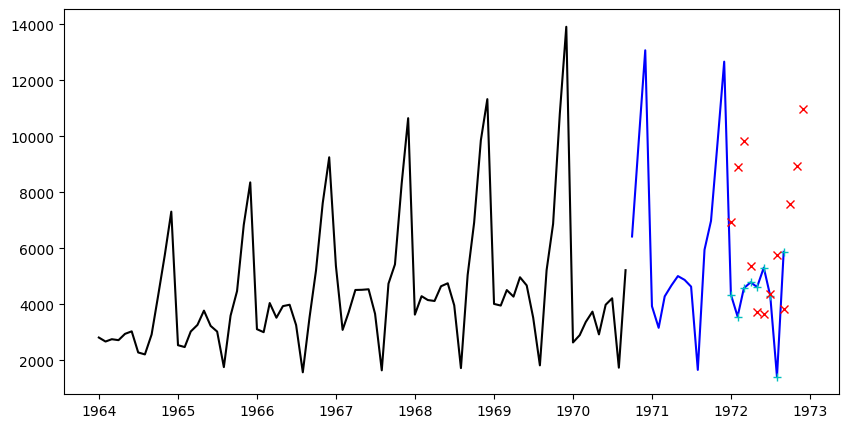

In [53]:
fig, ax = plt.subplots(figsize=(10, 5))
ax = plt.plot(df_champ_expandido.index[0:ind], df_champ_expandido['y'][0:ind], '-k')  # Datos de entrenamiento
ax = plt.plot(df_champ_expandido.index[ind:], df_champ_expandido['y'][ind:], '-b')    # Datos de test
ax = plt.plot(df_champ_expandido.index[-12:], df_champ_expandido['y'][-12:], '+c')    # Datos de test incluyendo solo los puntuales reales
ax = plt.plot(df_champ_expandido.index[-12:], pred_LSTM, 'xr')  # Predicciones puntuales del modelo del último año

Comentarios finales:


Las predicciones se realizaron con las siguietne técnicas:

1. Naive: Con esta técnica, se observa que sólo se toma el último dato y se replica, esto resulta ineficiente, ya que en la gráfica podemos observar que se pierde la estacionalidad y además tiene un error muy alto.
2. Seasonality Naive: Observamos que con el parámetro season_lenght, se hacen las predicciones con base a éste parámetro, como podemos observar el error vs las observaciones originales son mínimas. El error que tenemos con el seasonality es bajo comparado con el naive, por lo tanto, éste fue el que se tomó como referencia para los ejercicios.
3. Los datos de Prohet y LSTM, siento que me dió muy alta la RMSE, sin embargo para LSTM, la gráfica no muestra un comportamiento alterado.
4. Prophet cumple también con la tendencia, pero el área de error, es muy grande, lo cula me genera incertidumbre.

## **<<< Fin de la Actividad de la Semana - Pronósticos y Series de Tiempo >>>**